In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import seaborn as sns
from scipy import stats
import yfinance as yf

In [4]:
tw1 = pd.read_csv('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 1.csv')
tw2 = pd.read_csv('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 2.csv')
tw3 = pd.read_csv('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 3.csv')
tw4 = pd.read_csv('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 4.csv')
rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)
filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()

In [5]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID
0,D70,90.90,5.322000,912796Z28,Bill 6 Month,2/22/24,10/10/23,0.000,BUY,5.287500,5.338000
1,D67,0.00,93.625000,91282CGS4,Note 5.5 - 10 Year,3/31/30,10/4/23,3.625,SELL,93.648438,93.617188
2,D58,0.00,93.452957,91282CEN7,Note 3.5 - 5.5 Year,4/30/27,10/5/23,2.750,SELL,NaN,NaN
3,D36,126.25,95.480669,91282CFV8,Note 5.5 - 10 Year,11/15/32,10/12/23,4.125,BUY,95.511719,95.480469
4,D28,0.00,90.211138,91282CES6,Note 5.5 - 10 Year,5/31/29,10/12/23,2.750,BUY,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
69115,D45,378.75,5.252500,912797GD3,Bill 3 Month,1/18/24,12/29/23,0.000,BUY,5.205000,5.295000
69116,D58,0.00,87.359375,91282CAL5,Note 3.5 - 5.5 Year,9/30/27,12/20/23,0.375,SELL,87.406250,87.359375
69117,D50,0.00,96.175640,91282CAQ4,TIPS 0 - 5 year,10/15/25,12/22/23,0.125,SELL,96.281250,96.195313
69118,D70,0.00,83.410310,912810RR1,TIPS > 10 year,2/15/46,12/20/23,1.000,BUY,83.585938,83.234375


In [21]:
treasuries = pd.read_excel('/Users/jiangzixuan/Desktop/Blockhouse/Securities_Date_10_02_2024.xlsx')
filtered_treasuries = treasuries[['CUSIP','Security Type','Security Term','Maturity Date']]
filtered_treasuries.head()

,CUSIP,Security Type,Security Term,Maturity Date
0,912797MA2,Bill,4-Week,11/05/2024
1,912797ME4,Bill,8-Week,12/03/2024
2,912797NF0,Bill,17-Week,02/04/2025
3,912797LD7,Bill,42-Day,11/14/2024
4,912797MS3,Bill,52-Week,10/02/2025


Daily Volume:
TRADEDATE
2023-10-02    1.159082e+07
2023-10-03    4.331633e+06
2023-10-04    8.076986e+06
2023-10-05    6.345917e+06
2023-10-06    2.655604e+06
2023-10-10    3.018293e+06
2023-10-11    5.230631e+06
2023-10-12    6.522118e+06
2023-10-13    2.516788e+06
2023-10-16    5.980102e+06
2023-10-17    7.061860e+06
2023-10-18    5.867471e+06
2023-10-19    4.763018e+06
2023-10-20    3.035828e+06
2023-10-23    5.858830e+06
2023-10-24    4.045173e+06
2023-10-25    4.079390e+06
2023-10-26    4.320592e+06
2023-10-27    4.275581e+06
2023-10-30    3.322566e+06
2023-10-31    2.845056e+07
2023-12-01    3.506172e+06
2023-12-04    2.069042e+06
2023-12-05    3.647725e+06
2023-12-06    2.676233e+06
2023-12-07    2.956415e+06
2023-12-08    2.958551e+06
2023-12-11    2.310040e+06
2023-12-12    5.762176e+06
2023-12-13    3.557632e+06
2023-12-14    3.654971e+06
2023-12-15    1.033855e+07
2023-12-18    3.650618e+06
2023-12-19    1.005538e+07
2023-12-20    6.737247e+06
2023-12-21    5.168079e+06
2023

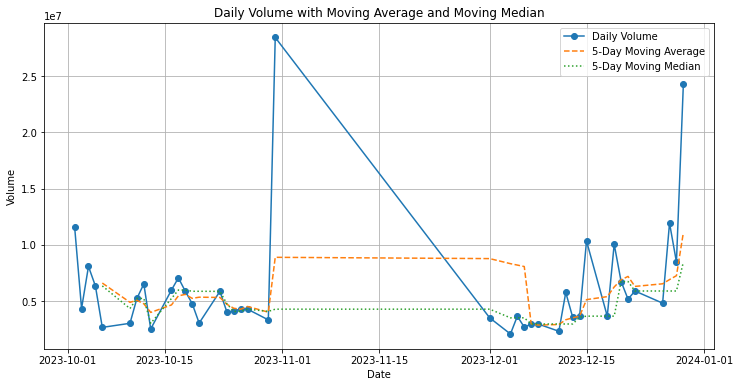

In [6]:
filtered_rawdata['TRADEDATE'] = pd.to_datetime(filtered_rawdata['TRADEDATE'])

daily_volume = filtered_rawdata.groupby('TRADEDATE')['ACCEPTEDVOL'].sum()
moving_average = daily_volume.rolling(window=5).mean()
moving_median = daily_volume.rolling(window=5).median()

# results
print("Daily Volume:")
print(daily_volume)
print("\n5-Day Moving Average:")
print(moving_average)
print("\n5-Day Moving Median:")
print(moving_median)

plt.figure(figsize=(12, 6))
plt.plot(daily_volume, label='Daily Volume', marker='o')
plt.plot(moving_average, label='5-Day Moving Average', linestyle='--')
plt.plot(moving_median, label='5-Day Moving Median', linestyle=':')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Daily Volume with Moving Average and Moving Median')
plt.legend()
plt.grid()
plt.show()

Daily Volume:
TRADEDATE
2023-10-02    1.159082e+07
2023-10-03    4.331633e+06
2023-10-04    8.076986e+06
2023-10-05    6.345917e+06
2023-10-06    2.655604e+06
2023-10-10    3.018293e+06
2023-10-11    5.230631e+06
2023-10-12    6.522118e+06
2023-10-13    2.516788e+06
2023-10-16    5.980102e+06
2023-10-17    7.061860e+06
2023-10-18    5.867471e+06
2023-10-19    4.763018e+06
2023-10-20    3.035828e+06
2023-10-23    5.858830e+06
2023-10-24    4.045173e+06
2023-10-25    4.079390e+06
2023-10-26    4.320592e+06
2023-10-27    4.275581e+06
2023-10-30    3.322566e+06
2023-10-31    2.845056e+07
2023-12-01    3.506172e+06
2023-12-04    2.069042e+06
2023-12-05    3.647725e+06
2023-12-06    2.676233e+06
2023-12-07    2.956415e+06
2023-12-08    2.958551e+06
2023-12-11    2.310040e+06
2023-12-12    5.762176e+06
2023-12-13    3.557632e+06
2023-12-14    3.654971e+06
2023-12-15    1.033855e+07
2023-12-18    3.650618e+06
2023-12-19    1.005538e+07
2023-12-20    6.737247e+06
2023-12-21    5.168079e+06
2023

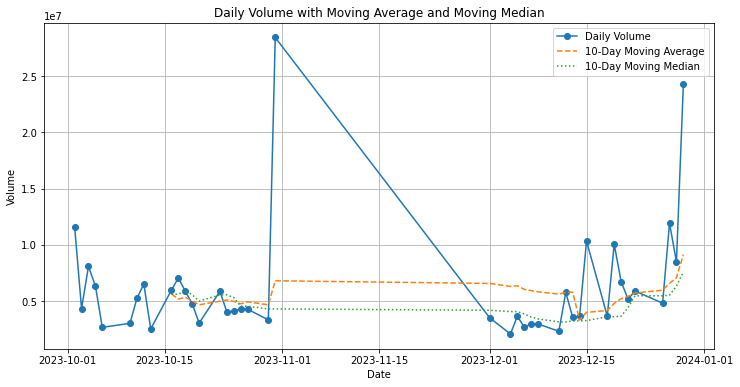

In [7]:
filtered_rawdata['TRADEDATE'] = pd.to_datetime(filtered_rawdata['TRADEDATE'])

daily_volume = filtered_rawdata.groupby('TRADEDATE')['ACCEPTEDVOL'].sum()
moving_average = daily_volume.rolling(window=10).mean()
moving_median = daily_volume.rolling(window=10).median()

# results
print("Daily Volume:")
print(daily_volume)
print("\n10-Day Moving Average:")
print(moving_average)
print("\n10-Day Moving Median:")
print(moving_median)

plt.figure(figsize=(12, 6))
plt.plot(daily_volume, label='Daily Volume', marker='o')
plt.plot(moving_average, label='10-Day Moving Average', linestyle='--')
plt.plot(moving_median, label='10-Day Moving Median', linestyle=':')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Daily Volume with Moving Average and Moving Median')
plt.legend()
plt.grid()
plt.show()

In [8]:
filtered_rawdata['TRADEDATE'] = pd.to_datetime(filtered_rawdata['TRADEDATE'])
filtered_rawdata['MATURITY_DATE'] = pd.to_datetime(filtered_rawdata['MATURITY_DATE'])

# Assume 'ISSUANCE_SIZE' column exists in the data; if not, you can manually add this
if 'ISSUANCE_SIZE' not in filtered_rawdata.columns:
    # Example: creating a mock issuance size column (assuming 100M issuance for each note)
    filtered_rawdata['ISSUANCE_SIZE'] = 100000000  

filtered_rawdata['Years_to_Maturity'] = (filtered_rawdata['MATURITY_DATE'] - filtered_rawdata['TRADEDATE']).dt.days / 365
filtered_rawdata['ISSUANCE_DATE'] = filtered_rawdata['TRADEDATE'] - pd.to_timedelta(filtered_rawdata['Years_to_Maturity'] * 365, unit='D')
filtered_rawdata['Age_of_Note'] = (filtered_rawdata['TRADEDATE'] - filtered_rawdata['ISSUANCE_DATE']).dt.days

# Calculate the daily volume as a percentage of the issuance size
filtered_rawdata['Volume_Percentage_of_Issuance'] = (filtered_rawdata['ACCEPTEDVOL'] / filtered_rawdata['ISSUANCE_SIZE']) * 100

# Calculate the cumulative volume traded since issuance
filtered_rawdata['Cumulative_Volume'] = filtered_rawdata.groupby('INSTRUMENT')['ACCEPTEDVOL'].cumsum()

# Calculate what percentage of the issuance has traded over time
filtered_rawdata['Percent_of_Issuance_Traded'] = (filtered_rawdata['Cumulative_Volume'] / filtered_rawdata['ISSUANCE_SIZE']) * 100

# Display the relevant columns
result = filtered_rawdata[['TRADEDATE', 'INSTRUMENT', 'Age_of_Note', 'Volume_Percentage_of_Issuance', 'Percent_of_Issuance_Traded']]
print(result.head())


   TRADEDATE INSTRUMENT  Age_of_Note  Volume_Percentage_of_Issuance  \
0 2023-10-10  912796Z28          135                       0.000091   
1 2023-10-04  91282CGS4         2370                       0.000000   
2 2023-10-05  91282CEN7         1303                       0.000000   
3 2023-10-12  91282CFV8         3322                       0.000126   
4 2023-10-12  91282CES6         2058                       0.000000   

   Percent_of_Issuance_Traded  
0                    0.000091  
1                    0.000000  
2                    0.000000  
3                    0.000126  
4                    0.000000  


In [69]:
# Ensure necessary imports
import pandas as pd

# Step 1: Calculate duration-based volume
# This uses a basic duration metric; for more complex measures, you might use a separate function
filtered_rawdata['Duration_Based_Volume'] = filtered_rawdata['ACCEPTEDVOL'] * filtered_rawdata['Years_to_Maturity']

# Step 2: Normalize duration-based volume across instruments by scaling against issuance size
filtered_rawdata['Normalized_Duration_Volume'] = filtered_rawdata['Duration_Based_Volume'] / filtered_rawdata['ISSUANCE_SIZE']

# Step 3: Intraday volume profile (e.g., hourly)
# Create an 'Hour' column to facilitate hourly analysis
filtered_rawdata['Hour'] = filtered_rawdata['TRADEDATE'].dt.hour
# Calculate cumulative intraday volume per hour for each instrument
filtered_rawdata['Intraday_Volume'] = filtered_rawdata.groupby(['INSTRUMENT', 'Hour'])['ACCEPTEDVOL'].cumsum()

# Step 4: Correlation Analysis Across Curve Points
# Calculate the cross-correlation matrix for the normalized duration volume at different maturities
# Resample data to aggregate volumes daily to capture liquidity across the curve points
daily_data = filtered_rawdata.resample('D', on='TRADEDATE').sum()
curve_points = daily_data.pivot_table(index='TRADEDATE', columns='Years_to_Maturity', values='Normalized_Duration_Volume')
correlation_matrix = curve_points.corr()

# Display liquidity-related metrics
result = filtered_rawdata[['TRADEDATE', 'INSTRUMENT', 'Age_of_Note', 'Volume_Percentage_of_Issuance', 
                           'Percent_of_Issuance_Traded', 'Duration_Based_Volume', 
                           'Normalized_Duration_Volume', 'Intraday_Volume']]
print(result.head())


   TRADEDATE INSTRUMENT  Age_of_Note  Volume_Percentage_of_Issuance  \
0 2023-10-10  912796Z28          135                       0.000091   
1 2023-10-04  91282CGS4         2370                       0.000000   
2 2023-10-05  91282CEN7         1303                       0.000000   
3 2023-10-12  91282CFV8         3322                       0.000126   
4 2023-10-12  91282CES6         2058                       0.000000   

   Percent_of_Issuance_Traded  Duration_Based_Volume  \
0                    0.000091              33.620548   
1                    0.000000               0.000000   
2                    0.000000               0.000000   
3                    0.000126            1149.047945   
4                    0.000000               0.000000   

   Normalized_Duration_Volume  Intraday_Volume  
0                3.362055e-07            90.90  
1                0.000000e+00             0.00  
2                0.000000e+00             0.00  
3                1.149048e-05           

In [13]:
def fetch_yield_curve_data(start_date, end_date):
    # Fetch daily yield curve data (daily interval)
    yield_10y = yf.download("^TNX", start=start_date, end=end_date, interval="1d")['Adj Close'] / 100  # 10-Year yield
    yield_2y = yf.download("^FVX", start=start_date, end=end_date, interval="1d")['Adj Close'] / 100  # 2-Year yield

    # Combine the data
    yield_data = pd.DataFrame({'Yield_10Y': yield_10y, 'Yield_2Y': yield_2y})

    # Resample to minute intervals by forward filling the daily data
    yield_data = yield_data.resample('1T').ffill()

    return yield_data
    
start = '2023-10-01'
end = '2023-10-31'
yield_data = fetch_yield_curve_data(start, end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [10]:
# Calculate slippage metrics
filtered_rawdata['mid_price'] = (filtered_rawdata['COMP_ASK'] + filtered_rawdata['COMP_BID']) / 2
filtered_rawdata['slippage'] = np.where(filtered_rawdata['SIDE'] == 'BUY',
                                      filtered_rawdata['PRICE'] - filtered_rawdata['mid_price'],
                                      filtered_rawdata['mid_price'] - filtered_rawdata['PRICE'])
filtered_rawdata['slippage_bps'] = filtered_rawdata['slippage'] / filtered_rawdata['mid_price'] * 10000

In [11]:
filtered_rawdata['slippage_bps'].dropna()

0        17.410945
1         0.834376
3        -1.615249
6        -0.819580
8        -0.819685
           ...    
69113    -1.257806
69115     4.761905
69116     2.682164
69117     6.509043
69118     0.018464
Name: slippage_bps, Length: 122252, dtype: float64

In [12]:
filtered_rawdata['spread_bps'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID']) / filtered_rawdata['mid_price'] * 10000
filtered_rawdata['trade_notional'] = filtered_rawdata['PRICE'] * filtered_rawdata['ACCEPTEDVOL']
filtered_rawdata['time_to_Maturity'] = filtered_rawdata['MATURITY_DATE']
filtered_rawdata['trade_notional'] = filtered_rawdata['PRICE'] * filtered_rawdata['ACCEPTEDVOL']
# Select features for analysis
features = ['ACCEPTEDVOL', 'spread_bps', 'trade_notional', 
           'COUPON_RATE', 'trade_notional']


In [14]:
filtered_rawdata['TRADEDATE'] = pd.to_datetime(filtered_rawdata['TRADEDATE'])
daily_volume = filtered_rawdata.groupby('TRADEDATE')['ACCEPTEDVOL'].sum()
moving_average = daily_volume.rolling(window=10).mean()
moving_median = daily_volume.rolling(window=10).median()

In [15]:
correlations = []
for feature in features:
    correlation = stats.spearmanr(filtered_rawdata[feature], 
                                filtered_rawdata['slippage_bps'],
                                nan_policy='omit')[0]
    correlations.append({
        'Feature': feature,
        'Correlation': abs(correlation)  # Use absolute correlation for ranking
    })

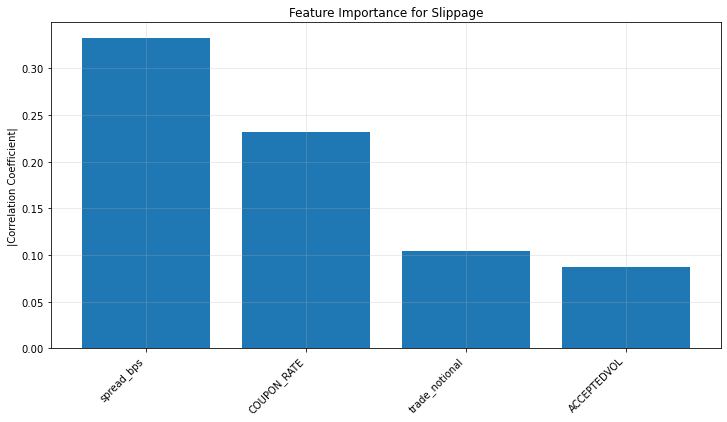

In [16]:
correlation_df = pd.DataFrame(correlations)
correlation_df = correlation_df.sort_values('Correlation', ascending=False)

# Create visualization
plt.figure(figsize=(12, 6))
bars = plt.bar(correlation_df['Feature'], correlation_df['Correlation'])
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance for Slippage')
plt.ylabel('|Correlation Coefficient|')
plt.grid(True, alpha=0.3)


In [55]:
correlation_df

,Feature,Correlation
1,spread_bps,0.332819
3,COUPON_RATE,0.231999
2,trade_notional,0.104562
4,trade_notional,0.104562
0,ACCEPTEDVOL,0.087393


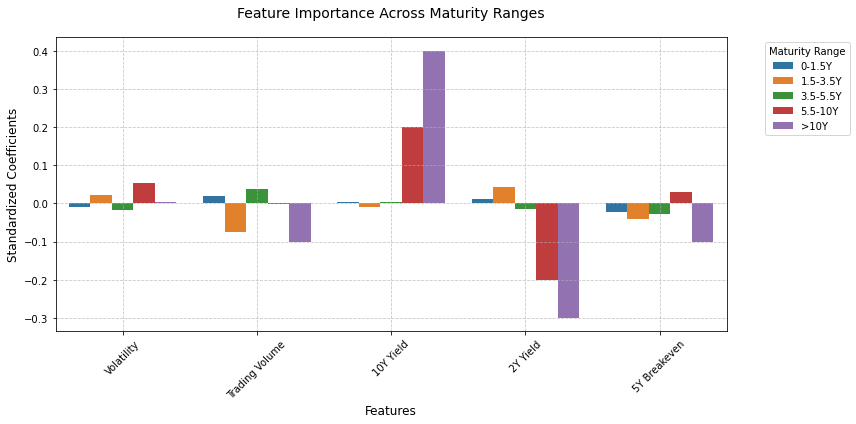

In [33]:
data = {
    'Feature': ['Volatility', 'Trading Volume', '10Y Yield', '2Y Yield', '5Y Breakeven'],
    '0-1.5Y': [-0.008156, 0.01884, 0.002674, 0.01063, -0.02229],
    '1.5-3.5Y': [0.02269, -0.07392, -0.01007, 0.042, -0.03998],
    '3.5-5.5Y': [-0.01791, 0.03812, 0.002816, -0.01519, -0.02724],
    '5.5-10Y': [0.05315, -0.0006096, 0.2, -0.2, 0.02972],
    '>10Y': [0.002581, -0.1, 0.4, -0.3, -0.1]
}

df = pd.DataFrame(data)

# Melt the DataFrame for seaborn
df_melted = pd.melt(df, id_vars=['Feature'], var_name='Maturity', value_name='Coefficient')

plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Coefficient', hue='Maturity', data=df_melted)

plt.title('Feature Importance Across Maturity Ranges', fontsize=14, pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Standardized Coefficients', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Maturity Range', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [ ]:
data = {
    'Feature': ['ACCEPTEDVOL', 'spread_bps', 'trade_notional','COUPON_RATE', 'trade_notional],
    '0-1.5Y': [-0.008156, 0.01884, 0.002674, 0.01063, -0.02229],
    '1.5-3.5Y': [0.02269, -0.07392, -0.01007, 0.042, -0.03998],
    '3.5-5.5Y': [-0.01791, 0.03812, 0.002816, -0.01519, -0.02724],
    '5.5-10Y': [0.05315, -0.0006096, 0.2, -0.2, 0.02972],
    '>10Y': [0.002581, -0.1, 0.4, -0.3, -0.1]
}

df = pd.DataFrame(data)

# Melt the DataFrame for seaborn
df_melted = pd.melt(df, id_vars=['Feature'], var_name='Maturity', value_name='Coefficient')

plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Coefficient', hue='Maturity', data=df_melted)

plt.title('Feature Importance Across Maturity Ranges', fontsize=14, pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Standardized Coefficients', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Maturity Range', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [49]:
def calculate_features_importance(data, maturity_range):
    # Filter for maturity range
    data_subset = data[data['MATURITY_RANGE'] == maturity_range].copy()
    
    # Calculate additional features
    data_subset['spread_bps'] = (data_subset['COMP_ASK'] - data_subset['COMP_BID']) * 100
    data_subset['trade_notional'] = data_subset['ACCEPTEDVOL'] * data_subset['PRICE']
    
    # Features to analyze
    features = ['ACCEPTEDVOL', 'spread_bps', 'trade_notional', 'COUPON_RATE', 'Volatility']
    
    # Standardize features
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(data_subset[features]), columns=features)
    
    # Target variable
    y = data_subset['slippage_bps']
    
    # Add constant
    X = sm.add_constant(X)
    
    # Fit regression
    model = sm.OLS(y, X).fit()
    
    return model.params[1:]  # Exclude constant


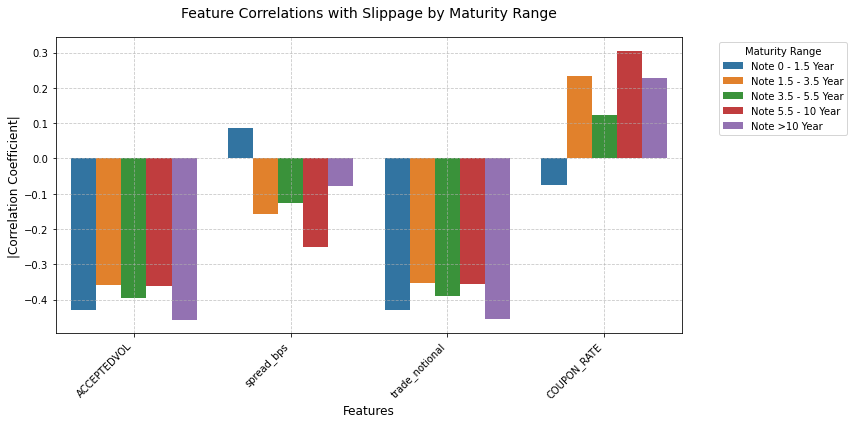


Average Absolute Correlations with Slippage:
COUPON_RATE          0.1636
spread_bps           -0.1060
trade_notional       -0.3972
ACCEPTEDVOL          -0.4004

Detailed Correlations by Maturity Range:
Maturity        Note 0 - 1.5 Year  Note 1.5 - 3.5 Year  Note 3.5 - 5.5 Year  \
Feature                                                                       
ACCEPTEDVOL               -0.4299              -0.3582              -0.3952   
COUPON_RATE               -0.0741               0.2351               0.1227   
spread_bps                 0.0854              -0.1563              -0.1277   
trade_notional            -0.4288              -0.3543              -0.3907   

Maturity        Note 5.5 - 10 Year  Note >10 Year  
Feature                                            
ACCEPTEDVOL                -0.3608        -0.4578  
COUPON_RATE                 0.3050         0.2294  
spread_bps                 -0.2522        -0.0790  
trade_notional             -0.3567        -0.4557  


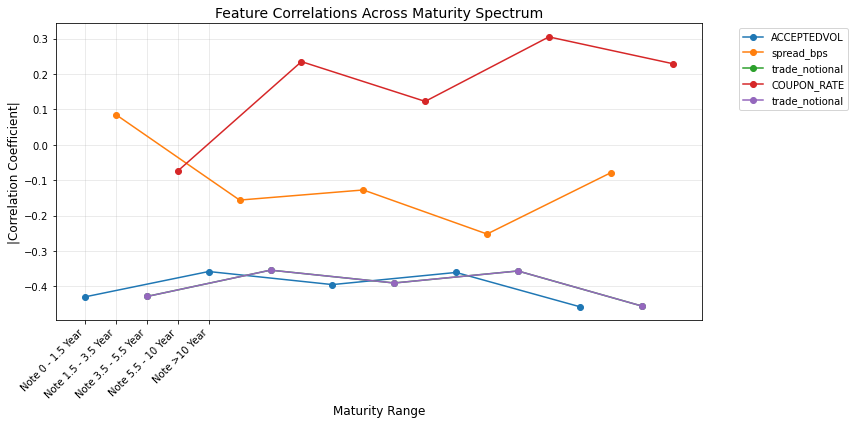

In [75]:
def calculate_correlations_by_maturity(data, maturity_range):
    # Filter for maturity range
    data_subset = data[data['MATURITY_RANGE'] == maturity_range].copy()
    features = ['ACCEPTEDVOL', 'spread_bps', 'trade_notional', 'COUPON_RATE']
    
    # Calculate correlations
    correlations = []
    for feature in features:
        correlation = stats.spearmanr(data_subset[feature], 
                                    data_subset['slippage_bps'],
                                    nan_policy='omit')[0]
        correlations.append({
            'Feature': feature,
            'Correlation': correlation,
            'Maturity': maturity_range
        })
    
    return correlations

# Maturity ranges
maturity_ranges = ['Note 0 - 1.5 Year', 'Note 1.5 - 3.5 Year', 'Note 3.5 - 5.5 Year', 
                  'Note 5.5 - 10 Year', 'Note >10 Year']

# Calculate correlations for each maturity range
all_correlations = []
for maturity in maturity_ranges:
    correlations = calculate_correlations_by_maturity(filtered_rawdata, maturity)
    all_correlations.extend(correlations)

# Convert to DataFrame
correlation_df = pd.DataFrame(all_correlations)

# Create visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=correlation_df, x='Feature', y='Correlation', hue='Maturity')

# Customize plot
plt.title('Feature Correlations with Slippage by Maturity Range', fontsize=14, pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('|Correlation Coefficient|', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Maturity Range', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nAverage Absolute Correlations with Slippage:")
print("==========================================")
avg_correlations = correlation_df.groupby('Feature')['Correlation'].mean().sort_values(ascending=False)
for feature, correlation in avg_correlations.items():
    print(f"{feature:<20} {correlation:.4f}")

# Print detailed correlations by maturity
print("\nDetailed Correlations by Maturity Range:")
print("=====================================")
pivot_table = correlation_df.pivot(index='Feature', columns='Maturity', values='Correlation')
print(pivot_table.round(4))

# Additional Analysis: Time series of correlations
plt.figure(figsize=(12, 6))
for feature in features:
    plt.plot(correlation_df[correlation_df['Feature'] == feature]['Correlation'], 
             label=feature, marker='o')

plt.title('Feature Correlations Across Maturity Spectrum', fontsize=14)
plt.xlabel('Maturity Range', fontsize=12)
plt.ylabel('|Correlation Coefficient|', fontsize=12)
plt.xticks(range(len(maturity_ranges)), maturity_ranges, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()